In [1]:
!nvidia-smi

Fri Jan 23 03:16:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:03:00.0 Off |                    0 |
| N/A   32C    P0             89W /  400W |       1MiB /  40960MiB |      6%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys
sys.path.append('./src')

In [3]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
import matplotlib as mpl
from matplotlib import pyplot as plt
import optax
tfd = tfp.distributions

In [4]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(500.0), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

Load the data. The ground truth parameters are in `truth`. Observation parameters, including the noise scale and exposure time are fixed.

The PSF is generated from `TinyTim` for HST F140W band, and has been supersampled to the pixel scale of 0.065.

In [5]:
truth = [[
    {'theta_E': 1.1, 'gamma': 2.0, 'e1': 0.1, 'e2': 0.1, 'center_y': 0.0, 'center_x': 0.1},
    {'gamma2': 0.03, 'gamma1': -0.01}
], [
    {'R_sersic': 0.8, 'n_sersic': 2.5, 'e1': 0.09534746574143645, 'e2': 0.14849487967198177, 'center_x': 0.1, 'center_y': 0.0, 'Ie': 499.3695906504067}
], [
    {'R_sersic': 0.25, 'n_sersic': 1.5, 'e1': 0., 'e2': 0., 'center_x': 0.09566681002252231, 'center_y': -0.0639623054267272, 'Ie': 149.58828877085668}
]]

In [6]:
kernel = np.load('./src/gigalens/assets/psf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = np.load('./src/gigalens/assets/demo.npy')
prob_model = ForwardProbModel(prior, observed_img, background_rms=0.2, exp_time=100)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

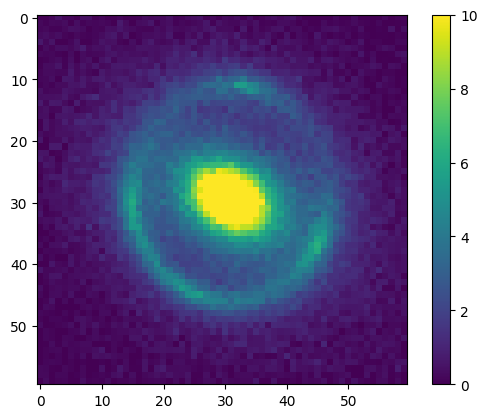

In [7]:
plt.imshow(observed_img, vmin=0, vmax=10)
plt.colorbar()

Sanity check: calculate residuals using ground truth.

Chi-square: 1.0069085


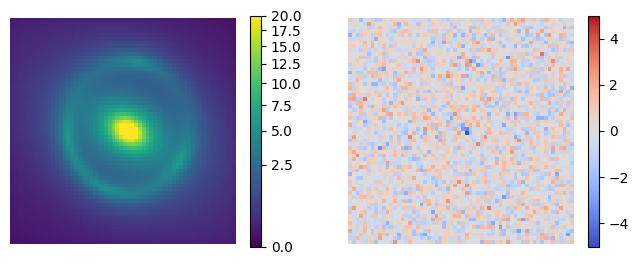

In [8]:
plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.imshow(lens_sim.simulate(truth), norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=20),)
plt.colorbar()
plt.axis('off')
plt.subplot(122)
simulated = lens_sim.simulate(truth)
resid = simulated - observed_img
background_rms, exp_time = 0.2, 100
err_map = np.sqrt(background_rms**2 + simulated/exp_time)
plt.imshow(resid/err_map, cmap='coolwarm', interpolation='none', vmin=-5, vmax=5)
print('Chi-square:', np.mean((resid/err_map)**2))
plt.axis('off')
plt.colorbar()

Begin fitting. We use `supersample=1` for this demonstration to speed things up, but setting `supersample=2` is recommended in practice. This will not significantly slow down the fitting.

In [9]:
opt = optax.adabelief(1e-2, b1=0.95, b2=0.99)
map_estimate = model_seq.MAP(opt, seed=0)

Chi-squared: 0.986: 100%|██████████| 350/350 [00:12<00:00, 27.95it/s]

Final Chi-squared: 0.98419


In [10]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate[0])[0]
best = map_estimate[0][jnp.nanargmax(lps)][jnp.newaxis,:]

In [11]:
opt = optax.adabelief(1e-4, b1=0.95, b2=0.99)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1500)

-ELBO: -73.617: 100%|██████████| 1500/1500 [00:55<00:00, 27.06it/s]


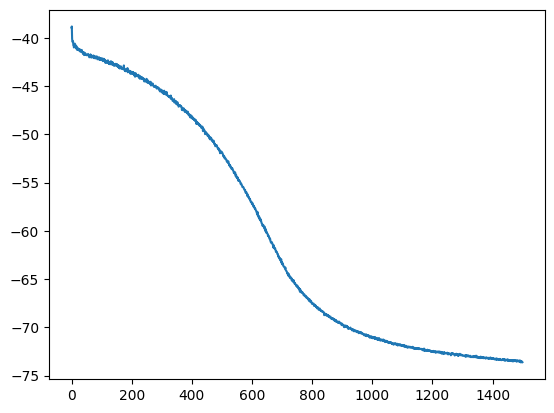

In [12]:
plt.plot(loss_hist)

Although the loss is still declining, the VI results are sufficient for our sampling.

In [13]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750,pbar_interval=25)

HMC Progress: 100%|██████████| 1000/1000 [00:26<00:00, 37.15it/s]

Sampling took 26.9s


In [14]:
rhat= tfp.mcmc.potential_scale_reduction(samples, independent_chain_ndims=2)
ess = tfp.mcmc.effective_sample_size(samples, cross_chain_dims=[1,2])

for i,r in enumerate(rhat): print(rhat[i],ess[i])

1.0003188 25131.256
1.002157 22944.812
1.0076599 8369.88
1.0065527 8371.309
1.0121542 4363.6426
1.0021535 14653.324
1.0073498 5940.5776
1.0046772 9139.492
1.0033073 13359.046
1.003545 12519.357
1.0012342 25199.53
1.0025699 24228.318
1.0006729 24908.33
1.0012728 25029.066
1.0037614 12060.332
1.0053985 8303.615
1.0060569 7455.2607
1.0005783 25173.861
1.0106711 4542.012
1.0009547 24683.496
1.0019156 25270.477
1.0048609 8837.573


In [15]:
smp = samples.reshape((-1, 22))
smp_physical = prob_model.bij.forward(list(smp.T))

tups = [(0, 0), (0, 1), (1, 0), (2, 0)]
label_prefixes = ["", "", "lens_", "src_"]
labels = []
for (i, j), label_prefix in zip(tups, label_prefixes):
    labels.extend((key for key in smp_physical[i][j].keys()))
plt_samples = np.vstack(
    [np.array(list(smp_physical[i][j].values())) for i, j in tups]
).T
mass_samps = plt_samples.T[0:8].T
mass_labels = labels[0:8]

In [16]:
markers = []
for i in truth[0][0].keys():
    markers.append(truth[0][0][i])
for j in truth[0][1].keys():
    markers.append(truth[0][1][j])

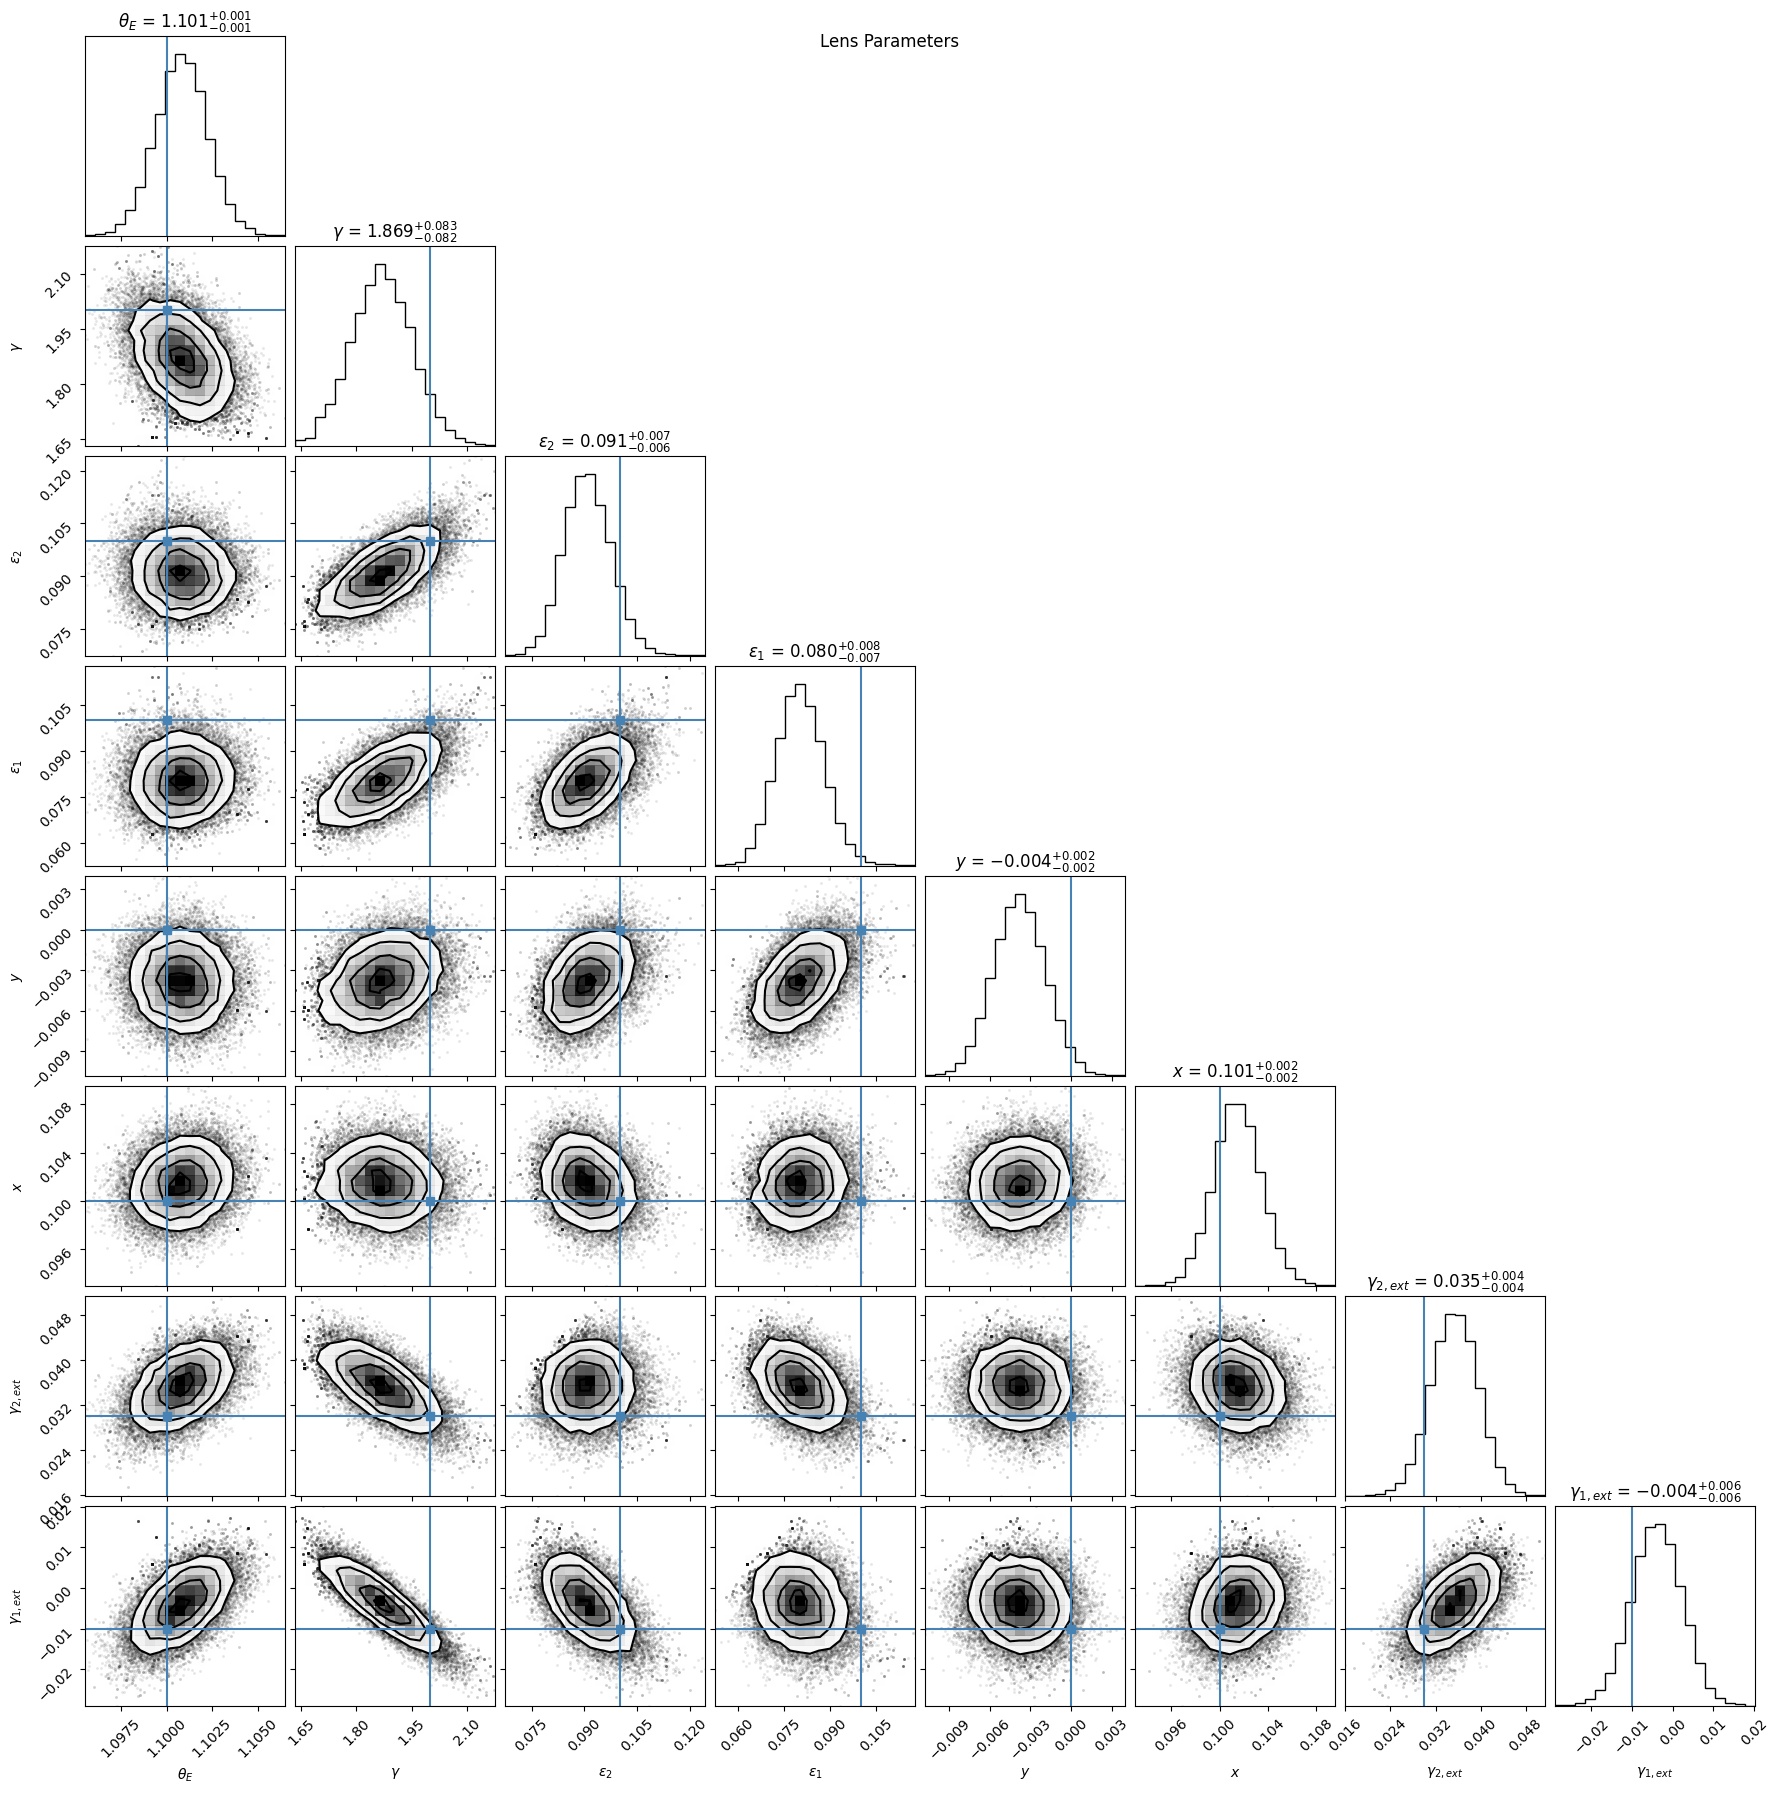

In [17]:
from corner import corner
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_2$', 
        r'$\epsilon_1$',
        r'$y$', r'$x$', 
        r'$\gamma_{2,ext}$',
        r'$\gamma_{1,ext}$',]

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels, truths=markers)
_ = fig.suptitle("Lens Parameters")